In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from optbinning import BinningProcess

In [2]:
credit_risk_data=pd.read_csv(r"C:\Users\SHREYA PAI\Files\PD Model\Data\credit_risk_dataset.csv")

In [3]:
credit_risk_data

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
0,22,59000,RENT,123.0,PERSONAL,D,35000,16.02,1,0.59,Y,3
1,21,9600,OWN,5.0,EDUCATION,B,1000,11.14,0,0.10,N,2
2,25,9600,MORTGAGE,1.0,MEDICAL,C,5500,12.87,1,0.57,N,3
3,23,65500,RENT,4.0,MEDICAL,C,35000,15.23,1,0.53,N,2
4,24,54400,RENT,8.0,MEDICAL,C,35000,14.27,1,0.55,Y,4
...,...,...,...,...,...,...,...,...,...,...,...,...
32576,57,53000,MORTGAGE,1.0,PERSONAL,C,5800,13.16,0,0.11,N,30
32577,54,120000,MORTGAGE,4.0,PERSONAL,A,17625,7.49,0,0.15,N,19
32578,65,76000,RENT,3.0,HOMEIMPROVEMENT,B,35000,10.99,1,0.46,N,28
32579,56,150000,MORTGAGE,5.0,PERSONAL,B,15000,11.48,0,0.10,N,26


In [4]:
credit_risk_data.describe()

,person_age,person_income,person_emp_length,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_cred_hist_length
count,32581.000000,3.258100e+04,31686.000000,32581.000000,29465.000000,32581.000000,32581.000000,32581.000000
mean,27.734600,6.607485e+04,4.789686,9589.371106,11.011695,0.218164,0.170203,5.804211
std,6.348078,6.198312e+04,4.142630,6322.086646,3.240459,0.413006,0.106782,4.055001
min,20.000000,4.000000e+03,0.000000,500.000000,5.420000,0.000000,0.000000,2.000000
25%,23.000000,3.850000e+04,2.000000,5000.000000,7.900000,0.000000,0.090000,3.000000
50%,26.000000,5.500000e+04,4.000000,8000.000000,10.990000,0.000000,0.150000,4.000000
75%,30.000000,7.920000e+04,7.000000,12200.000000,13.470000,0.000000,0.230000,8.000000
max,144.000000,6.000000e+06,123.000000,35000.000000,23.220000,1.000000,0.830000,30.000000


In [5]:
credit_risk_data_cpy=credit_risk_data.copy()

**Drop Duplicates**

In [6]:
credit_risk_data_dplct_rmvd=credit_risk_data.drop_duplicates()

credit_risk_data_dplct_rmvd

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
0,22,59000,RENT,123.0,PERSONAL,D,35000,16.02,1,0.59,Y,3
1,21,9600,OWN,5.0,EDUCATION,B,1000,11.14,0,0.10,N,2
2,25,9600,MORTGAGE,1.0,MEDICAL,C,5500,12.87,1,0.57,N,3
3,23,65500,RENT,4.0,MEDICAL,C,35000,15.23,1,0.53,N,2
4,24,54400,RENT,8.0,MEDICAL,C,35000,14.27,1,0.55,Y,4
...,...,...,...,...,...,...,...,...,...,...,...,...
32576,57,53000,MORTGAGE,1.0,PERSONAL,C,5800,13.16,0,0.11,N,30
32577,54,120000,MORTGAGE,4.0,PERSONAL,A,17625,7.49,0,0.15,N,19
32578,65,76000,RENT,3.0,HOMEIMPROVEMENT,B,35000,10.99,1,0.46,N,28
32579,56,150000,MORTGAGE,5.0,PERSONAL,B,15000,11.48,0,0.10,N,26


**Check for null values**

In [7]:
credit_risk_data_dplct_rmvd.isnull().sum()

person_age                       0
person_income                    0
person_home_ownership            0
person_emp_length              887
loan_intent                      0
loan_grade                       0
loan_amnt                        0
loan_int_rate                 3095
loan_status                      0
loan_percent_income              0
cb_person_default_on_file        0
cb_person_cred_hist_length       0
dtype: int64

**Handle null values using bucket-wise filling**

**Median for loan_int_rate and Mean for person_emp_length**

In [8]:
credit_risk_data_dplct_rmvd['person_emp_length']=credit_risk_data_dplct_rmvd['person_emp_length'].fillna(credit_risk_data_dplct_rmvd.groupby('person_age')['person_emp_length'].transform('median')).fillna('bfill')

In [9]:
credit_risk_data_dplct_rmvd['loan_int_rate']=credit_risk_data_dplct_rmvd['loan_int_rate'].fillna(credit_risk_data_dplct_rmvd.groupby('loan_amnt')['loan_int_rate'].transform('median')).fillna('bfill')

**Verify there are no null values**

In [10]:
credit_risk_data_dplct_rmvd.isnull().sum()

person_age                    0
person_income                 0
person_home_ownership         0
person_emp_length             0
loan_intent                   0
loan_grade                    0
loan_amnt                     0
loan_int_rate                 0
loan_status                   0
loan_percent_income           0
cb_person_default_on_file     0
cb_person_cred_hist_length    0
dtype: int64

**Making data type uniform**

In [11]:
credit_risk_data_dplct_rmvd.dtypes

person_age                      int64
person_income                   int64
person_home_ownership             str
person_emp_length             float64
loan_intent                       str
loan_grade                        str
loan_amnt                       int64
loan_int_rate                  object
loan_status                     int64
loan_percent_income           float64
cb_person_default_on_file         str
cb_person_cred_hist_length      int64
dtype: object

In [12]:
credit_risk_data_dplct_rmvd=credit_risk_data_dplct_rmvd.astype({'person_age': 'float', 'person_income': 'float', 'loan_amnt': 'float', 'cb_person_cred_hist_length': 'float'})
credit_risk_data_dplct_rmvd.dtypes

person_age                    float64
person_income                 float64
person_home_ownership             str
person_emp_length             float64
loan_intent                       str
loan_grade                        str
loan_amnt                     float64
loan_int_rate                  object
loan_status                     int64
loan_percent_income           float64
cb_person_default_on_file         str
cb_person_cred_hist_length    float64
dtype: object

**Removing leaky features**

In [13]:
credit_risk_loan_grade_rmvd=credit_risk_data_dplct_rmvd.drop(columns=['loan_grade'])
credit_risk_loan_grade_rmvd

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
0,22.0,59000.0,RENT,123.0,PERSONAL,35000.0,16.02,1,0.59,Y,3.0
1,21.0,9600.0,OWN,5.0,EDUCATION,1000.0,11.14,0,0.10,N,2.0
2,25.0,9600.0,MORTGAGE,1.0,MEDICAL,5500.0,12.87,1,0.57,N,3.0
3,23.0,65500.0,RENT,4.0,MEDICAL,35000.0,15.23,1,0.53,N,2.0
4,24.0,54400.0,RENT,8.0,MEDICAL,35000.0,14.27,1,0.55,Y,4.0
...,...,...,...,...,...,...,...,...,...,...,...
32576,57.0,53000.0,MORTGAGE,1.0,PERSONAL,5800.0,13.16,0,0.11,N,30.0
32577,54.0,120000.0,MORTGAGE,4.0,PERSONAL,17625.0,7.49,0,0.15,N,19.0
32578,65.0,76000.0,RENT,3.0,HOMEIMPROVEMENT,35000.0,10.99,1,0.46,N,28.0
32579,56.0,150000.0,MORTGAGE,5.0,PERSONAL,15000.0,11.48,0,0.10,N,26.0


**Removing Outliers**

In [14]:
credit_risk_loan_grade_rmvd.pivot_table(index="person_age", columns="loan_status", values="person_income", aggfunc="count").sort_values(by="person_age")

loan_status,0,1
person_age,,
20.0,13.0,2.0
21.0,843.0,370.0
22.0,2725.0,882.0
23.0,3029.0,832.0
24.0,2759.0,767.0
25.0,2349.0,674.0
26.0,1946.0,516.0
27.0,1684.0,443.0
28.0,1437.0,411.0


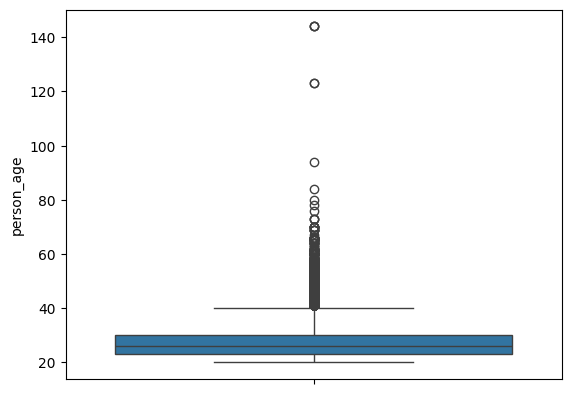

In [15]:
sns.boxplot(data=credit_risk_loan_grade_rmvd['person_age'])
plt.show()

In [16]:
credit_risk_age_rmvd=credit_risk_loan_grade_rmvd[credit_risk_loan_grade_rmvd['person_age']<=70]

In [17]:
credit_risk_age_rmvd.describe()

,person_age,person_income,person_emp_length,loan_amnt,loan_status,loan_percent_income,cb_person_cred_hist_length
count,32403.000000,3.240300e+04,32403.000000,32403.000000,32403.000000,32403.000000,32403.000000
mean,27.717742,6.589997e+04,4.765948,9594.235102,0.218776,0.170269,5.806345
std,6.158069,5.252614e+04,4.085024,6322.882338,0.413423,0.106813,4.047126
min,20.000000,4.000000e+03,0.000000,500.000000,0.000000,0.000000,2.000000
25%,23.000000,3.850000e+04,2.000000,5000.000000,0.000000,0.090000,3.000000
50%,26.000000,5.500000e+04,4.000000,8000.000000,0.000000,0.150000,4.000000
75%,30.000000,7.920000e+04,7.000000,12250.000000,0.000000,0.230000,8.000000
max,70.000000,2.039784e+06,123.000000,35000.000000,1.000000,0.830000,30.000000


In [18]:
credit_risk_age_rmvd.pivot_table(index="person_emp_length", columns="loan_status", values="person_income", aggfunc="count").reset_index().sort_values(by="person_emp_length")

loan_status,person_emp_length,0,1
0,0.0,2941.0,1143.0
1,0.5,1.0,NaN
2,1.0,2093.0,803.0
3,2.0,2843.0,987.0
4,3.0,2773.0,720.0
5,4.0,2825.0,860.0
6,4.5,6.0,4.0
7,5.0,2378.0,548.0
8,6.0,2154.0,498.0
9,6.5,1.0,NaN


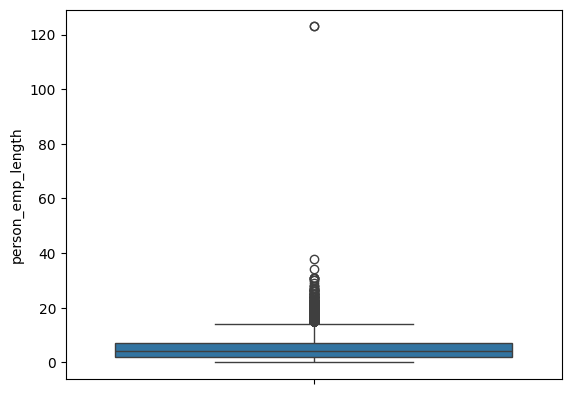

In [19]:
sns.boxplot(data=credit_risk_age_rmvd['person_emp_length'])
plt.show()

In [20]:
credit_risk_emp_len_rmvd=credit_risk_age_rmvd[credit_risk_age_rmvd['person_emp_length']<=40]

In [21]:
credit_risk_emp_len_rmvd.reset_index(drop=True, inplace=True)

In [22]:
credit_risk_emp_len_rmvd.describe()

,person_age,person_income,person_emp_length,loan_amnt,loan_status,loan_percent_income,cb_person_cred_hist_length
count,32401.000000,3.240100e+04,32401.000000,32401.000000,32401.000000,32401.000000,32401.000000
mean,27.718126,6.589629e+04,4.758649,9593.129842,0.218759,0.170259,5.806487
std,6.158064,5.252307e+04,3.978126,6321.237562,0.413411,0.106791,4.047209
min,20.000000,4.000000e+03,0.000000,500.000000,0.000000,0.000000,2.000000
25%,23.000000,3.850000e+04,2.000000,5000.000000,0.000000,0.090000,3.000000
50%,26.000000,5.500000e+04,4.000000,8000.000000,0.000000,0.150000,4.000000
75%,30.000000,7.920000e+04,7.000000,12250.000000,0.000000,0.230000,8.000000
max,70.000000,2.039784e+06,38.000000,35000.000000,1.000000,0.830000,30.000000


In [23]:
credit_risk_cleaned_data=credit_risk_emp_len_rmvd

In [24]:
cr_data=credit_risk_cleaned_data.copy()

**Encoding categorical variable using WoE**

In [25]:
feature_names=['person_age',
          'person_income',
          'person_emp_length',
          'loan_amnt',
          'loan_int_rate',
          'loan_percent_income',
          'cb_person_cred_hist_length',
          'person_home_ownership',     #categorical
          'loan_intent',               #categorical
          'cb_person_default_on_file'  #categorical
]

categorical_variables=['person_home_ownership',     #categorical
          'loan_intent',               #categorical
          'cb_person_default_on_file'
                      ]

X= credit_risk_cleaned_data[feature_names]
y=credit_risk_cleaned_data['loan_status']

binning_process=BinningProcess(
    variable_names=feature_names,
    categorical_variables=categorical_variables
)

binning_process.fit(X, y)
X_woe=binning_process.transform(X, metric="woe")

print("Shape after WoE encoding: ", X_woe.shape)
print(X_woe.head())

Shape after WoE encoding:  (32401, 10)
   person_age  person_income  person_emp_length  loan_amnt  loan_int_rate  \
0   -0.223093      -1.823091           0.192049   0.008924       0.234565   
1    0.002406      -1.823091          -0.314438   0.449240      -0.005272   
2    0.002406       0.441380          -0.009388  -0.725965       0.126146   
3    0.002406       0.072268           0.285230  -0.725965      -0.005272   
4   -0.223093      -1.823091          -0.214970   0.008924       1.236284   

   loan_percent_income  cb_person_cred_hist_length  person_home_ownership  \
0             0.653267                   -0.103728               1.240657   
1            -2.260428                   -0.029947               0.661754   
2            -2.260428                   -0.103728              -0.501602   
3            -2.260428                   -0.029947              -0.501602   
4             0.139005                   -0.103728               1.240657   

   loan_intent  cb_person_default_o

In [26]:
iv_summary=binning_process.summary()
iv_table=iv_summary[['name', 'iv']].sort_values('iv', ascending=False).reset_index(drop=True)
iv_table.columns=['Features', 'IV']
iv_table['Predictive_Power']=iv_table['IV'].apply(lambda x:
                                                  'Strong (>0.3)' if x>0.3 else
                                                  'Medium (0.1-0.3)' if x>0.1 else
                                                  'Weak (0.02-0.1)' if x>0.02 else
                                                  'Useless (<0.02)'
                                                 )
print(iv_table)

                     Features        IV  Predictive_Power
0         loan_percent_income  0.949654     Strong (>0.3)
1               loan_int_rate  0.902662     Strong (>0.3)
2               person_income  0.567417     Strong (>0.3)
3       person_home_ownership  0.375772     Strong (>0.3)
4   cb_person_default_on_file  0.163908  Medium (0.1-0.3)
5                 loan_intent   0.09601   Weak (0.02-0.1)
6                   loan_amnt  0.091599   Weak (0.02-0.1)
7           person_emp_length  0.059403   Weak (0.02-0.1)
8                  person_age  0.010918   Useless (<0.02)
9  cb_person_cred_hist_length  0.004786   Useless (<0.02)


In [27]:
X_woe_final=X_woe.drop(columns=['person_age', 'cb_person_cred_hist_length'])

print(X_woe_final.columns.tolist())
print(X_woe_final.shape)

['person_income', 'person_emp_length', 'loan_amnt', 'loan_int_rate', 'loan_percent_income', 'person_home_ownership', 'loan_intent', 'cb_person_default_on_file']
(32401, 8)


**Train-test data**

In [28]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_woe_final, y,
    test_size=0.2,
    random_state=42
)

print("Train size: ", X_train.shape)
print("Test size: ", X_test.shape)
print("\nTrain class distribution:")
print(y_train.value_counts())
print("\nTest class distribution:")
print(y_test.value_counts())

Train size:  (25920, 8)
Test size:  (6481, 8)

Train class distribution:
loan_status
0    20230
1     5690
Name: count, dtype: int64

Test class distribution:
loan_status
0    5083
1    1398
Name: count, dtype: int64


**SMOTE Balancing**

In [29]:
pip install imblearn

Defaulting to user installation because normal site-packages is not writeableNote: you may need to restart the kernel to use updated packages.



In [30]:
pip install xgboost

Defaulting to user installation because normal site-packages is not writeableNote: you may need to restart the kernel to use updated packages.



In [31]:
from imblearn.over_sampling import SMOTE

smote=SMOTE(random_state=42)
X_train_bal, y_train_bal=smote.fit_resample(X_train, y_train)

print("Balanced Train Class Distribution:")
print(y_train_bal.value_counts())


Balanced Train Class Distribution:
loan_status
1    20230
0    20230
Name: count, dtype: int64


In [32]:
print("\nTest set default rate:", round(y_test.mean()*100, 2))


Test set default rate: 21.57


In [33]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.calibration import CalibratedClassifierCV

**Logistic Regression**

In [34]:
logit=LogisticRegression(max_iter=1000, random_state=42)
logit.fit(X_train_bal, y_train_bal)
logit_cal=CalibratedClassifierCV(estimator=logit, method='sigmoid', cv=None)
logit_cal.fit(X_train_bal, y_train_bal)

,"estimator estimator: estimator instance, default=NoneThe classifier whose output need to be calibrated to provide moreaccurate `predict_proba` outputs. The default classifier isa :class:`~sklearn.svm.LinearSVC`... versionadded:: 1.2",LogisticRegre...ndom_state=42)
,"method method: {'sigmoid', 'isotonic', 'temperature'}, default='sigmoid'The method to use for calibration. Can be:- 'sigmoid', which corresponds to Platt's method (i.e. a binary logistic regression model).- 'isotonic', which is a non-parametric approach.- 'temperature', temperature scaling.Sigmoid and isotonic calibration methods natively support only binaryclassifiers and extend to multi-class classification using a One-vs-Rest (OvR)strategy with post-hoc renormalization, i.e., adjusting the probabilities aftercalibration to ensure they sum up to 1.In contrast, temperature scaling naturally supports multi-class calibration byapplying `softmax(classifier_logits/T)` with a value of `T` (temperature)that optimizes the log loss.For very uncalibrated classifiers on very imbalanced datasets, sigmoidcalibration might be preferred because it fits an additional interceptparameter. This helps shift decision boundaries appropriately when theclassifier being calibrated is biased towards the majority class.Isotonic calibration is not recommended when the number of calibration samplesis too low ``(≪1000)`` since it then tends to overfit... versionchanged:: 1.8 Added option 'temperature'.",'sigmoid'
,"cv cv: int, cross-validation generator, or iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross-validation,- integer, to specify the number of folds.- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if ``y`` is binary or multiclass,:class:`~sklearn.model_selection.StratifiedKFold` is used. If ``y`` isneither binary nor multiclass, :class:`~sklearn.model_selection.KFold`is used.Refer to the :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",None
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors.Base estimator clones are fitted in parallel across cross-validationiterations.See :term:`Glossary ` for more details... versionadded:: 0.24",None
,"ensemble ensemble: bool, or ""auto"", default=""auto""Determines how the calibrator is fitted.""auto"" will use `False` if the `estimator` is a:class:`~sklearn.frozen.FrozenEstimator`, and `True` otherwise.If `True`, the `estimator` is fitted using training data, andcalibrated using testing data, for each `cv` fold. The final estimatoris an ensemble of `n_cv` fitted classifier and calibrator pairs, where`n_cv` is the number of cross-validation folds. The output is theaverage predicted probabilities of all pairs.If `False`, `cv` is used to compute unbiased predictions, via:func:`~sklearn.model_selection.cross_val_predict`, which are thenused for calibration. At prediction time, the classifier used is the`estimator` trained on all the data.Note that this method is also internally implemented in:mod:`sklearn.svm` estimators with the `probabilities=True` parameter... versionadded:: 0.24.. versionchanged:: 1.6 `""auto""` option is added and is the default.",'auto'
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. dep

**Random Forest**

In [35]:
rf=RandomForestClassifier(n_estimators=200,
                         max_depth=6,
                         min_samples_leaf=50,
                         min_samples_split=100,
                         random_state=42
)
rf.fit(X_train_bal, y_train_bal)
rf_cal=CalibratedClassifierCV(estimator=rf, method='sigmoid', cv=None)
rf_cal.fit(X_train_bal, y_train_bal)

,"estimator estimator: estimator instance, default=NoneThe classifier whose output need to be calibrated to provide moreaccurate `predict_proba` outputs. The default classifier isa :class:`~sklearn.svm.LinearSVC`... versionadded:: 1.2",RandomForestC...ndom_state=42)
,"method method: {'sigmoid', 'isotonic', 'temperature'}, default='sigmoid'The method to use for calibration. Can be:- 'sigmoid', which corresponds to Platt's method (i.e. a binary logistic regression model).- 'isotonic', which is a non-parametric approach.- 'temperature', temperature scaling.Sigmoid and isotonic calibration methods natively support only binaryclassifiers and extend to multi-class classification using a One-vs-Rest (OvR)strategy with post-hoc renormalization, i.e., adjusting the probabilities aftercalibration to ensure they sum up to 1.In contrast, temperature scaling naturally supports multi-class calibration byapplying `softmax(classifier_logits/T)` with a value of `T` (temperature)that optimizes the log loss.For very uncalibrated classifiers on very imbalanced datasets, sigmoidcalibration might be preferred because it fits an additional interceptparameter. This helps shift decision boundaries appropriately when theclassifier being calibrated is biased towards the majority class.Isotonic calibration is not recommended when the number of calibration samplesis too low ``(≪1000)`` since it then tends to overfit... versionchanged:: 1.8 Added option 'temperature'.",'sigmoid'
,"cv cv: int, cross-validation generator, or iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross-validation,- integer, to specify the number of folds.- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if ``y`` is binary or multiclass,:class:`~sklearn.model_selection.StratifiedKFold` is used. If ``y`` isneither binary nor multiclass, :class:`~sklearn.model_selection.KFold`is used.Refer to the :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",None
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors.Base estimator clones are fitted in parallel across cross-validationiterations.See :term:`Glossary ` for more details... versionadded:: 0.24",None
,"ensemble ensemble: bool, or ""auto"", default=""auto""Determines how the calibrator is fitted.""auto"" will use `False` if the `estimator` is a:class:`~sklearn.frozen.FrozenEstimator`, and `True` otherwise.If `True`, the `estimator` is fitted using training data, andcalibrated using testing data, for each `cv` fold. The final estimatoris an ensemble of `n_cv` fitted classifier and calibrator pairs, where`n_cv` is the number of cross-validation folds. The output is theaverage predicted probabilities of all pairs.If `False`, `cv` is used to compute unbiased predictions, via:func:`~sklearn.model_selection.cross_val_predict`, which are thenused for calibration. At prediction time, the classifier used is the`estimator` trained on all the data.Note that this method is also internally implemented in:mod:`sklearn.svm` estimators with the `probabilities=True` parameter... versionadded:: 0.24.. versionchanged:: 1.6 `""auto""` option is added and is the default.",'auto'
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gin

**XGBoost**

In [36]:
xgb=XGBClassifier(max_depth=3,
                  learning_rate=0.03,
                  n_estimators=300,
                  subsample=0.7,
                  reg_lambda=5,
                  reg_alpha=1,
                  random_state=42,
                  evil_metric='logloss'
)
xgb.fit(X_train_bal, y_train_bal)
xgb_cal=CalibratedClassifierCV(estimator=xgb, method='sigmoid', cv=None)
xgb_cal.fit(X_train_bal, y_train_bal)

C:\Users\SHREYA PAI\AppData\Roaming\Python\Python312\site-packages\xgboost\training.py:200: UserWarning: [17:36:31] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "evil_metric" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
C:\Users\SHREYA PAI\AppData\Roaming\Python\Python312\site-packages\xgboost\training.py:200: UserWarning: [17:36:32] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "evil_metric" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
C:\Users\SHREYA PAI\AppData\Roaming\Python\Python312\site-packages\xgboost\training.py:200: UserWarning: [17:36:33] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "evil_metric" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
C:\Users\SHREYA PAI\AppData\Roaming\Python\Python312\site-packages\xgboost\training.py:200: UserWarning: [17:36:33] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learne

,"estimator estimator: estimator instance, default=NoneThe classifier whose output need to be calibrated to provide moreaccurate `predict_proba` outputs. The default classifier isa :class:`~sklearn.svm.LinearSVC`... versionadded:: 1.2","XGBClassifier...obs=None, ...)"
,"method method: {'sigmoid', 'isotonic', 'temperature'}, default='sigmoid'The method to use for calibration. Can be:- 'sigmoid', which corresponds to Platt's method (i.e. a binary logistic regression model).- 'isotonic', which is a non-parametric approach.- 'temperature', temperature scaling.Sigmoid and isotonic calibration methods natively support only binaryclassifiers and extend to multi-class classification using a One-vs-Rest (OvR)strategy with post-hoc renormalization, i.e., adjusting the probabilities aftercalibration to ensure they sum up to 1.In contrast, temperature scaling naturally supports multi-class calibration byapplying `softmax(classifier_logits/T)` with a value of `T` (temperature)that optimizes the log loss.For very uncalibrated classifiers on very imbalanced datasets, sigmoidcalibration might be preferred because it fits an additional interceptparameter. This helps shift decision boundaries appropriately when theclassifier being calibrated is biased towards the majority class.Isotonic calibration is not recommended when the number of calibration samplesis too low ``(≪1000)`` since it then tends to overfit... versionchanged:: 1.8 Added option 'temperature'.",'sigmoid'
,"cv cv: int, cross-validation generator, or iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross-validation,- integer, to specify the number of folds.- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if ``y`` is binary or multiclass,:class:`~sklearn.model_selection.StratifiedKFold` is used. If ``y`` isneither binary nor multiclass, :class:`~sklearn.model_selection.KFold`is used.Refer to the :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",None
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors.Base estimator clones are fitted in parallel across cross-validationiterations.See :term:`Glossary ` for more details... versionadded:: 0.24",None
,"ensemble ensemble: bool, or ""auto"", default=""auto""Determines how the calibrator is fitted.""auto"" will use `False` if the `estimator` is a:class:`~sklearn.frozen.FrozenEstimator`, and `True` otherwise.If `True`, the `estimator` is fitted using training data, andcalibrated using testing data, for each `cv` fold. The final estimatoris an ensemble of `n_cv` fitted classifier and calibrator pairs, where`n_cv` is the number of cross-validation folds. The output is theaverage predicted probabilities of all pairs.If `False`, `cv` is used to compute unbiased predictions, via:func:`~sklearn.model_selection.cross_val_predict`, which are thenused for calibration. At prediction time, the classifier used is the`estimator` trained on all the data.Note that this method is also internally implemented in:mod:`sklearn.svm` estimators with the `probabilities=True` parameter... versionadded:: 0.24.. versionchanged:: 1.6 `""auto""` option is added and is the default.",'auto'
,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: typing.Union[float, typing.List[

**Generate Predictions**

In [37]:
y_prob_logit=logit_cal.predict_proba(X_test)[:, 1]
y_prob_rf=rf_cal.predict_proba(X_test)[:, 1]
y_prob_xgb=xgb_cal.predict_proba(X_test)[:, 1]

**Classification Report**

In [38]:
from sklearn.metrics import classification_report

threshold=0.5

for name, y_prob in [
    ('Logistic Regression', y_prob_logit),
    ('Random Forest', y_prob_rf),
    ('XGBoost', y_prob_xgb)
]:
    y_pred=(y_prob>=threshold).astype(int)
    print(f"\n{'='*45}")
    print(f"{name}")
    print(f"\n{'='*45}")
    print(classification_report(y_test, y_pred, target_names=['Non-default', 'Default']))
    


Logistic Regression

              precision    recall  f1-score   support

 Non-default       0.93      0.83      0.88      5083
     Default       0.55      0.78      0.65      1398

    accuracy                           0.82      6481
   macro avg       0.74      0.80      0.76      6481
weighted avg       0.85      0.82      0.83      6481


Random Forest

              precision    recall  f1-score   support

 Non-default       0.93      0.88      0.91      5083
     Default       0.64      0.76      0.69      1398

    accuracy                           0.86      6481
   macro avg       0.78      0.82      0.80      6481
weighted avg       0.87      0.86      0.86      6481


XGBoost

              precision    recall  f1-score   support

 Non-default       0.93      0.93      0.93      5083
     Default       0.74      0.73      0.73      1398

    accuracy                           0.89      6481
   macro avg       0.83      0.83      0.83      6481
weighted avg       0.89   

**Confusion Matrix**

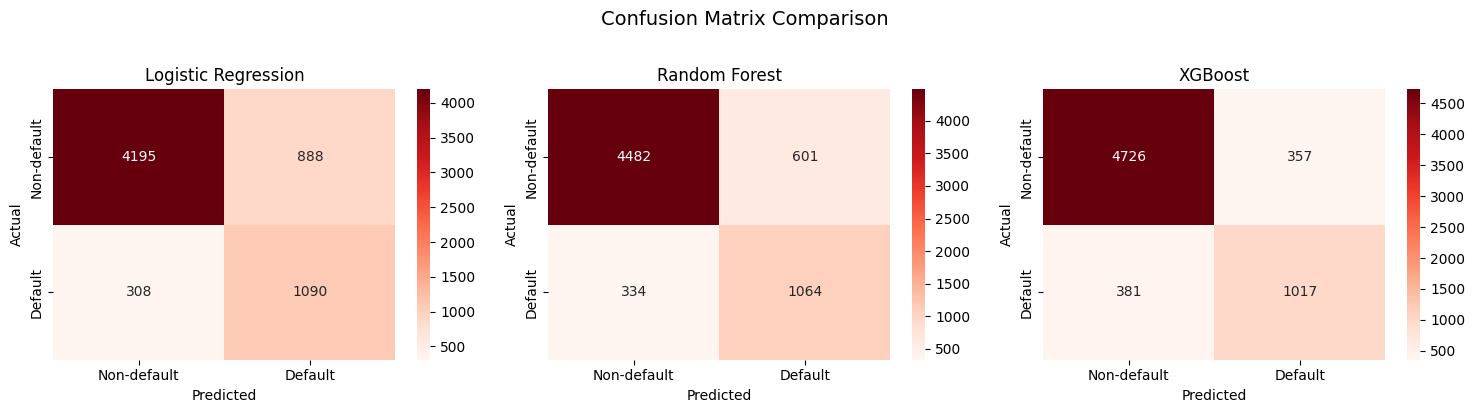

In [39]:
from sklearn.metrics import confusion_matrix

fig, axes=plt.subplots(1, 3, figsize=(15, 4))

for ax, (name, y_prob) in zip(axes, [
    ('Logistic Regression', y_prob_logit),
    ('Random Forest', y_prob_rf),
    ('XGBoost', y_prob_xgb)
]):
         y_pred=y_pred=(y_prob>=threshold).astype(int)
         cm=confusion_matrix(y_test, y_pred)

         sns.heatmap(
             cm, annot=True, fmt='d', cmap='Reds', ax=ax,
             xticklabels=['Non-default', 'Default'],
             yticklabels=['Non-default', 'Default']
         )
         ax.set_title(name)
         ax.set_ylabel('Actual')
         ax.set_xlabel('Predicted')

plt.suptitle('Confusion Matrix Comparison', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

**AUC, Gini, KS, Mean PD**

In [40]:
from sklearn.metrics import roc_auc_score
from scipy.stats import ks_2samp

results=[]
for name, y_prob in [
    ('Logistic Regression', y_prob_logit),
    ('Random Forest', y_prob_rf),
    ('XGBoost', y_prob_xgb)
]:
    auc=round(roc_auc_score(y_test, y_prob), 2)
    gini=round(2*auc-1, 2)
    ks=round(ks_2samp(
        y_prob[y_test==1],
        y_prob[y_test==0]
    ).statistic, 2)
    mean_pd=round(np.mean(y_prob), 3)

    results.append({
        'Model': name,
        'AUC': auc,
        'Gini': gini,
        'KS': ks,
        'Mean PD': mean_pd  
    })

results_df=pd.DataFrame(results)
print(results_df)
print(f"\nActual portfolio default rate: {round(y_test.mean(), 3)}")

                 Model   AUC  Gini    KS  Mean PD
0  Logistic Regression  0.88  0.76  0.62    0.363
1        Random Forest  0.89  0.78  0.65    0.322
2              XGBoost  0.91  0.82  0.66    0.272

Actual portfolio default rate: 0.216


**ROC Curves**

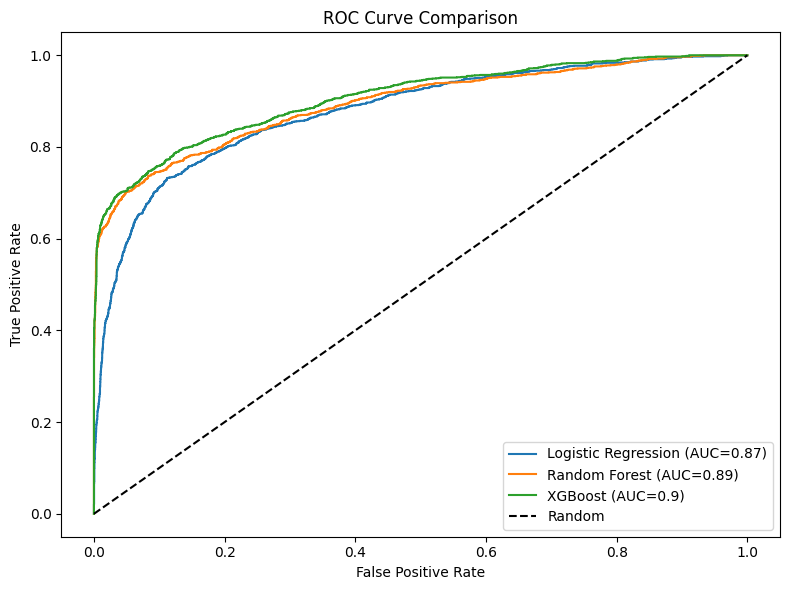

In [41]:
from sklearn.metrics import roc_curve

fig, ax=plt.subplots(figsize=(8, 6))

for name, y_prob, auc in [
    ('Logistic Regression', y_prob_logit, 0.87),
    ('Random Forest', y_prob_rf, 0.89),
    ('XGBoost', y_prob_xgb, 0.90)
]:
    fpr, tpr, _= roc_curve(y_test, y_prob)
    ax.plot(fpr, tpr, label=f'{name} (AUC={auc})')

ax.plot([0, 1], [0, 1], 'k--', label='Random')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curve Comparison')
ax.legend()
plt.tight_layout()
plt.show()


**Feature Importance**

In [42]:
logit_importance=pd.DataFrame({
    'Features': X_woe_final.columns,
    'Importance': np.abs(logit.coef_[0])
})

logit_importance['Model']='Logistic Regression'

rf_importance=pd.DataFrame({
    'Features': X_woe_final.columns,
    'Importance': rf.feature_importances_
})

rf_importance['Model']='Random Forest'

xgb_importance=pd.DataFrame({
    'Features': X_woe_final.columns,
    'Importance': xgb.feature_importances_
})

xgb_importance['Model']='XGBoost'

feat_importance=pd.concat([logit_importance, rf_importance, xgb_importance])

feat_importance['Norm_Importance']=feat_importance.groupby('Model')['Importance'].transform(
    lambda x: x/x.sum()
)

feat_importance['Rank']=feat_importance.groupby('Model')['Norm_Importance'].rank(ascending=False)

rank_matrix=feat_importance.pivot(index='Features', columns='Model', values='Rank')
print('Feature Importance Ranks (1 = Most Important):')
print(rank_matrix)

Feature Importance Ranks (1 = Most Important):
Model                      Logistic Regression  Random Forest  XGBoost
Features                                                              
cb_person_default_on_file                  7.0            7.0      8.0
loan_amnt                                  6.0            6.0      7.0
loan_int_rate                              2.0            1.0      2.0
loan_intent                                1.0            5.0      5.0
loan_percent_income                        4.0            2.0      1.0
person_emp_length                          8.0            8.0      6.0
person_home_ownership                      5.0            4.0      3.0
person_income                              3.0            3.0      4.0


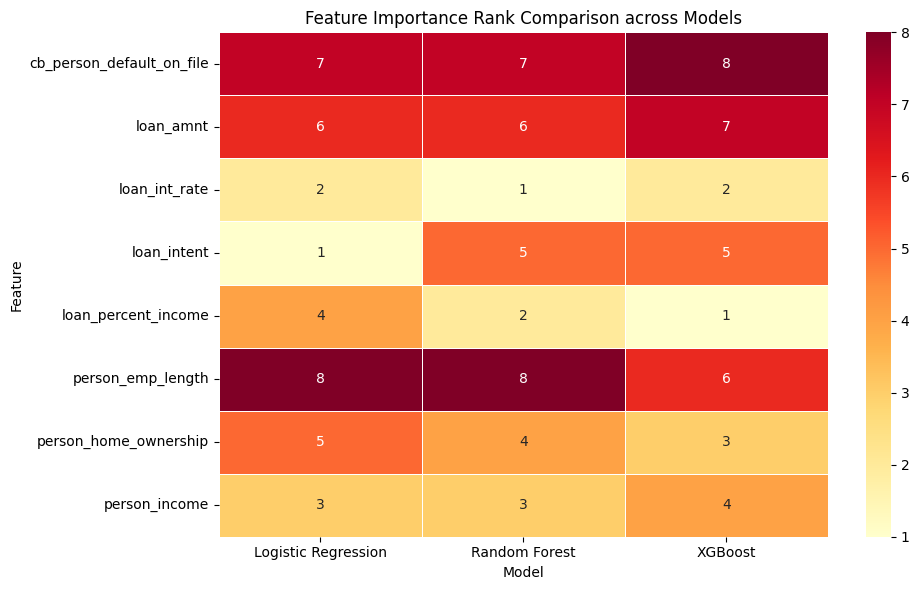

In [43]:
plt.figure(figsize=(10, 6))
sns.heatmap(
    rank_matrix,
    annot=True,
    fmt='.0f',
    cmap='YlOrRd',
    linewidth=0.5
)

plt.title('Feature Importance Rank Comparison across Models')
plt.xlabel('Model')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()



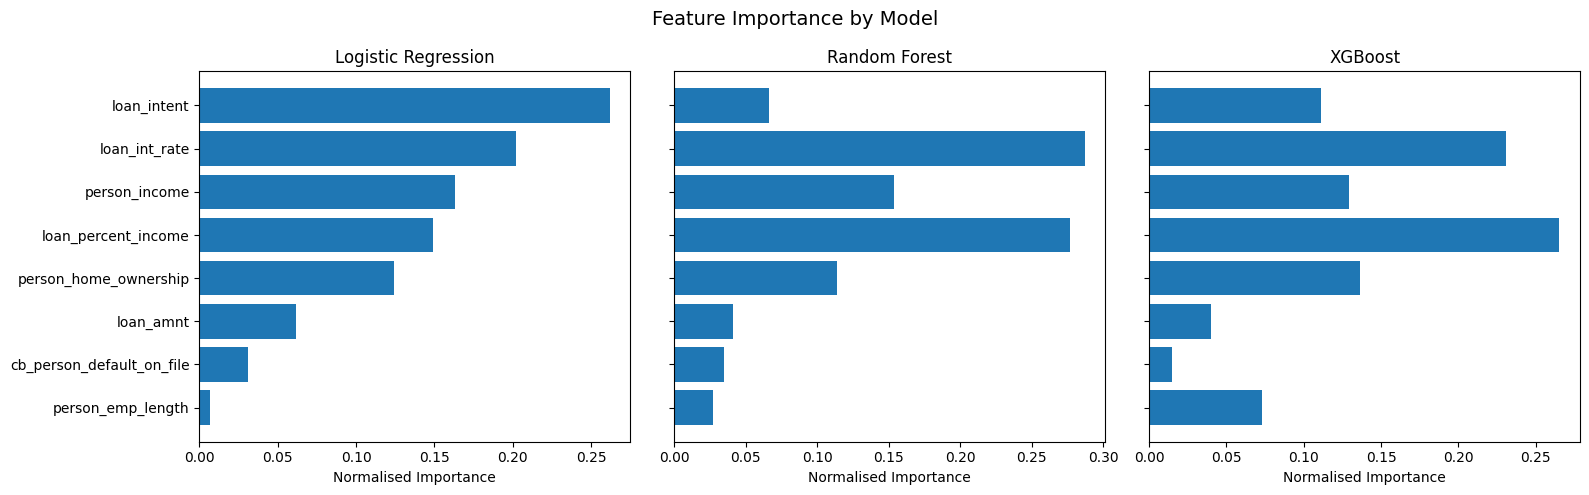

In [44]:
fig, axes=plt.subplots(1, 3, figsize=(16, 5), sharey=True)

for ax, model_name in zip(axes, [
    'Logistic Regression',
    'Random Forest',
    'XGBoost'
]):
    data=feat_importance[feat_importance['Model']== model_name].sort_values(
        'Norm_Importance', ascending=True
    )
    ax.barh(data['Features'], data['Norm_Importance'])
    ax.set_title(model_name)
    ax.set_xlabel('Normalised Importance')

plt.suptitle('Feature Importance by Model', fontsize=14)
plt.tight_layout()
plt.show()
    

**PSI**

In [45]:
y_prob_train_logit=logit_cal.predict_proba(X_train)[:, 1]
y_prob_train_rf=rf_cal.predict_proba(X_train)[:, 1]
y_prob_train_xgb=xgb_cal.predict_proba(X_train)[:, 1]

In [46]:
def calculate_psi(train_scores, test_scores, buckets=10):

    train_scores=np.asarray(train_scores, dtype=float).ravel()
    test_scores=np.asarray(test_scores, dtype=float).ravel()


    #Create decile break points based on train scores
    quantiles=np.linspace(0, 100, buckets+1)
    breakpoints=np.percentile(train_scores, quantiles)

    train_buckets=np.digitize(train_scores, breakpoints[1:-1])
    test_buckets=np.digitize(test_scores, breakpoints[1:-1])

    psi=0.0
    for i in range(buckets):
        train_pct=np.sum(train_buckets==i)/len(train_scores)
        test_pct=np.sum(test_buckets==i)/len(test_scores)
        
        #Avoid log(0) - replace zeroes with small values
        train_pct=max(train_pct, 0.0001)
        test_pct=max(test_pct, 0.0001)
        
        psi+=(test_pct-train_pct)*np.log(test_pct/train_pct)

    return round(psi, 4)

psi_logit=calculate_psi(y_prob_train_logit, y_prob_logit)
psi_rf=calculate_psi(y_prob_train_rf, y_prob_rf)
psi_xgb=calculate_psi(y_prob_train_xgb, y_prob_xgb)

print(f"Logistic Regression PSI: {psi_logit}")
print(f"Random Forest PSI: {psi_rf}")
print(f"XGBoost PSI: {psi_xgb}")


Logistic Regression PSI: 0.0011
Random Forest PSI: 0.001
XGBoost PSI: 0.0017


In [47]:
results_df['PSI']=[psi_logit, psi_rf, psi_xgb]

results_df['PSI Status']=results_df['PSI'].apply(lambda x:
                                                 'Stable' if x<0.10 else
                                                 'Monitor' if x<0.25 else
                                                 'Unstable'
                                                )

print(results_df)

                 Model   AUC  Gini    KS  Mean PD     PSI PSI Status
0  Logistic Regression  0.88  0.76  0.62    0.363  0.0011     Stable
1        Random Forest  0.89  0.78  0.65    0.322  0.0010     Stable
2              XGBoost  0.91  0.82  0.66    0.272  0.0017     Stable


**ECL Prediction**

In [51]:
#ECL=PD*LGD*EAD
#Using XGBoost for PD (Model with better results)
#LGD=45% (Basel foundation IRB standard assumption)
#EAD=loan_amnt (outstanding exposure)

LGD=0.45

#Get PD for full cleaned dataset
#Use the same X_woe_final built during encoding

y_prob_full=xgb_cal.predict_proba(X_woe_final)[:, 1]

#Built ECL dataframe
ecl_df=credit_risk_cleaned_data[['loan_amnt', 'loan_status']].copy().reset_index(drop=True)
ecl_df['PD']=y_prob_full
ecl_df['LGD']=LGD
ecl_df['EAD']=ecl_df['loan_amnt']
ecl_df['ECL']=ecl_df['PD']*ecl_df['LGD']*ecl_df['EAD']

#Portfolio Summary
total_ead=ecl_df['EAD'].sum()
total_ecl=ecl_df['ECL'].sum()
mean_pd=ecl_df['PD'].mean()
actual_def_rate=ecl_df['loan_status'].mean()
ecl_pct=total_ecl/total_ead

print("="*40)
print(" Portfolio ECL Summary - IFRS9")
print("="*40)
print(f"Total Portfolio EAD: ${total_ead:>15,.0f}")
print(f"Total Portfolio ECL: ${total_ecl:>15,.0f}")
print(f"ECL as % of portfolio: {ecl_pct:>14.2%}")
print(f"Mean PD: {mean_pd:>14.2%}")
print(f"Actual Default Rate: {actual_def_rate:>14.2%}")
print("="*40)


 Portfolio ECL Summary - IFRS9
Total Portfolio EAD: $    310,827,000
Total Portfolio ECL: $     42,545,435
ECL as % of portfolio:         13.69%
Mean PD:         27.82%
Actual Default Rate:         21.88%


**IFRS-9**

In [49]:
ecl_by_intent=ecl_df.merge(
    credit_risk_cleaned_data[['loan_intent']].reset_index(drop=True),
    left_index=True,
    right_index=True
)

ecl_summary=ecl_by_intent.groupby('loan_intent').agg(
    Loan_Count=('EAD', 'count'),
    Total_EAD=('EAD', 'sum'),
    Total_ECL=('ECL', 'sum'),
    Mean_PD=('PD', 'mean')
).reset_index()

ecl_summary['ECL_Rate']=ecl_summary['Total_ECL']/ecl_summary['Total_EAD']
ecl_summary=ecl_summary.round(3)
print(ecl_summary)


         loan_intent  Loan_Count   Total_EAD    Total_ECL  Mean_PD  ECL_Rate
0  DEBTCONSOLIDATION        5189  49841750.0  8485804.758    0.339     0.170
1          EDUCATION        6409  60750200.0  6859382.674    0.230     0.113
2    HOMEIMPROVEMENT        3594  37241475.0  5623040.714    0.318     0.151
3            MEDICAL        6036  55977975.0  9430551.135    0.336     0.168
4           PERSONAL        5494  52614100.0  7080429.565    0.284     0.135
5            VENTURE        5679  54401500.0  5066226.008    0.186     0.093


**Calibration Table**

In [50]:
cal_df=pd.DataFrame({
    'actual': y_test.values,
    'pred_pd': y_prob_xgb
})

cal_df['decile']= pd.qcut(
    cal_df['pred_pd'],
    q=10,
    labels=[f'D{i}'for i in range(1, 11)]
)

cal_table=cal_df.groupby('decile', observed=True).agg(
    Obs=('actual', 'count'),
    Defaults=('actual', 'sum'),
    Mean_Pred_PD=('pred_pd', 'mean'),
).reset_index()

cal_table['Actual_DR']=(cal_table['Defaults']/cal_table['Obs']).round(3)
cal_table['Mean_Pred_PD']=cal_table['Mean_Pred_PD'].round(3)
cal_table['Diff']=(cal_table['Mean_Pred_PD']- cal_table['Actual_DR']).round(3)

print(cal_table.to_string(index=False))

decile  Obs  Defaults  Mean_Pred_PD  Actual_DR   Diff
    D1  649         4         0.028      0.006  0.022
    D2  648        20         0.035      0.031  0.004
    D3  648        32         0.044      0.049 -0.005
    D4  648        19         0.057      0.029  0.028
    D5  648        48         0.077      0.074  0.003
    D6  648        71         0.112      0.110  0.002
    D7  648        76         0.184      0.117  0.067
    D8  648       131         0.381      0.202  0.179
    D9  648       358         0.820      0.552  0.268
   D10  648       639         0.987      0.986  0.001
